# Load the Murphy pharmacology data

Run all cells with Python (NumPy, pandas, SciPy, matplotlib and Jupyter). Uses the **extracted folders only** in `data/Murphy_pharma`; no MATLAB installation or zip extraction is needed.

Outputs:
- `metadata_df`: one row per participant × session × run, including drug and H mappings.
- `trials_df`: one row per stored trial, retaining invalid responses and incomplete trials.
- `stimuli_df`: one row per planned, non-padding sample, with a flag indicating whether its onset was recorded. Trial lengths vary, so this table is needed.
- `blocks_df`, `coverage_df`, `checks_df`: file provenance, coverage and sanity checks.

Indices are **1-based**, matching MATLAB and filenames. Join trials to metadata on `participant, session, run`; join samples to trials on `trial_id`. Nothing is written back to the source data.

In [1]:
from pathlib import Path
import io
import numpy as np
import pandas as pd
import scipy
from scipy.io import loadmat
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "data/Murphy_pharma").is_dir()), None)
if ROOT is None:
    raise FileNotFoundError("Run from the repository or a subfolder containing data/Murphy_pharma above it.")
DATA_DIR = ROOT / "data/Murphy_pharma"
pd.set_option("display.max_columns", 24)
print(f"Data: {DATA_DIR}\nSciPy: {scipy.__version__}")

Data: /workspaces/Copy_Murphy2021/data/Murphy_pharma
SciPy: 1.11.4


## Decode the metadata

`H` has dimensions participant × session × run. The participant ordering is taken from the embedded `drug_map` table, **not** guessed from directory order, and checked against `gen.H` in every stimulus file.

SciPy exposes the MATLAB table as an opaque MCOS object. The small decoder below reads its embedded workspace and validates this file's known table layout. It uses SciPy's private MAT reader; a changed MATLAB serialization or incompatible SciPy version will raise an explicit error rather than silently assign drugs. The source label **`donepizil` is preserved verbatim**.

In [2]:
def read_drug_map(path):
    from scipy.io.matlab._mio5 import MatFile5Reader
    raw = loadmat(path)
    try:
        payload = raw["__function_workspace__"].tobytes()
        if payload[2:4] != b"IM":
            raise ValueError("Expected a little-endian MATLAB workspace")
        reader = MatFile5Reader(io.BytesIO(payload), struct_as_record=False, squeeze_me=True)
        reader.byte_order = "<"
        reader.initialize_read()
        reader.mat_stream.seek(8)  # Embedded workspace has an 8-byte mini-header.
        header, _ = reader.read_var_header()
        workspace = reader.read_var_array(header)
        parts = workspace.MCOS["arr"][0]
        names = list(parts[7])
        if names != ["subj", "sess", "drug"] or int(parts[6]) != 3:
            raise ValueError(f"Unexpected table columns: {names}")
        table = pd.DataFrame(dict(zip(names, parts[2])))
        if len(table) != int(parts[4]):
            raise ValueError("MATLAB table row count mismatch")
    except Exception as exc:
        raise ValueError("Cannot decode this drug_map MATLAB table; inspect its serialization before proceeding.") from exc
    return raw["H"], table.rename(columns={"subj": "participant", "sess": "session"})

H, drug_map_df = read_drug_map(DATA_DIR / "meta_data_drug.mat")
drug_map_df["session"] = drug_map_df["session"].astype(int)
participants = drug_map_df["participant"].drop_duplicates().tolist()
assert H.shape == (len(participants), 3, 2)
assert not drug_map_df.duplicated(["participant", "session"]).any()
assert drug_map_df.groupby("participant")["session"].agg(set).apply(lambda x: x == {1, 2, 3}).all()
assert drug_map_df.groupby("participant")["drug"].nunique().eq(3).all()
metadata_df = pd.DataFrame([
    {"participant": p, "session": s, "run": r, "H": float(H[i, s-1, r-1])}
    for i, p in enumerate(participants) for s in (1, 2, 3) for r in (1, 2)
]).merge(drug_map_df, on=["participant", "session"], validate="many_to_one")
assert metadata_df.groupby(["participant", "session"])["H"].agg(set).apply(lambda x: x == {0.1, 0.9}).all()
print(f"{len(participants)} participants; {len(drug_map_df)} session mappings; {len(metadata_df)} run mappings")
display(metadata_df.head(12))
display(pd.crosstab(drug_map_df["session"], drug_map_df["drug"]))

30 participants; 90 session mappings; 180 run mappings


,participant,session,run,H,drug
0,CMC,1,1,0.9,atomoxetine
1,CMC,1,2,0.1,atomoxetine
2,CMC,2,1,0.1,placebo
3,CMC,2,2,0.9,placebo
4,CMC,3,1,0.9,donepizil
5,CMC,3,2,0.1,donepizil
6,CPG,1,1,0.1,donepizil
7,CPG,1,2,0.9,donepizil
8,CPG,2,1,0.1,placebo
9,CPG,2,2,0.9,placebo


drug,atomoxetine,donepizil,placebo
session,,,
1,10,10,10
2,10,10,10
3,10,10,10


## Load paired behavior and stimulus blocks

Files are paired by their relative run folder and exact filename. The filename's last number is the block number; it is local to the run. Both `participant/participant/S*/R*` and `participant/S*/R*` extraction layouts work. Missing runs/blocks are reported, never fabricated. Some saved behavior blocks are shorter than the planned sequence: only their leading trial rows are loaded, with sample counts and final distributions checked for alignment. `blocks_df.n_planned_trials` retains the full planned count.

Field meanings come from the executable code in `task_decision/Surprise_radial_checkers_trial.m` (the header comment is outdated) and `Surprise_radial_checkers_block.m`:

| Field | Meaning |
|---|---|
| `final_distribution`, `response` | Raw codes: 1 = left, 2 = right; response 99 = invalid key/double press |
| `accuracy` | 0/1; NaN for invalid response |
| `rt_s` | Seconds from response cue |
| `start_time_raw` | Task clock value, retained without assuming a calendar timestamp |
| `fixation_break_count` | Sum of fixation-check flags; **not** an abort indicator or necessarily a count of distinct saccades |
| `stimulus_value` | Raw angular position from `stimIn` (zero is a valid stimulus) |
| `generating_distribution`, `switch` | `distseqs` (1/2) and `pswitch` (0/1); first switch entry is 0 |
| `onset_s` | `tRefresh`, seconds relative to trial start; zero padding is not an onset |

There is no explicit abort flag. `presentation_complete` means all planned samples have positive finite onsets. `valid_response` means response 1/2 and finite accuracy. `analysis_valid` requires both, excluding invalid responses and incomplete presentations conservatively. Fixation breaks are retained separately. These files cannot recover trials from blocks that were never saved.

In [3]:
behavior_files = sorted(DATA_DIR.rglob("Behaviour/*.mat"))
sequence_files = set(DATA_DIR.rglob("Sample_seqs/*.mat"))
if not behavior_files:
    raise FileNotFoundError("No extracted Behaviour/*.mat files found")
paired_sequences = {f.parent.parent / "Sample_seqs" / f.name for f in behavior_files}
assert not (paired_sequences - sequence_files), "Behavior blocks missing stimulus files"
unpaired_sequences_df = pd.DataFrame({"source_sequence": [str(p.relative_to(DATA_DIR))
    for p in sorted(sequence_files - paired_sequences)]})
print(f"Stimulus files without behavior: {len(unpaired_sequences_df)} (not treated as observed trials)")
display(unpaired_sequences_df)
meta_lookup = metadata_df.set_index(["participant", "session", "run"])
trial_parts, sample_parts, block_rows = [], [], []

for behavior_path in behavior_files:
    run_path = behavior_path.parent.parent
    session_path = run_path.parent
    participant = session_path.parent.name
    session, run = int(session_path.name[1:]), int(run_path.name[1:])
    name_participant, name_session, name_block = behavior_path.stem.split("_")
    assert (name_participant, int(name_session)) == (participant, session)
    block = int(name_block)
    meta = meta_lookup.loc[(participant, session, run)]
    sequence_path = run_path / "Sample_seqs" / behavior_path.name
    behavior = loadmat(behavior_path)
    sequence = loadmat(sequence_path, simplify_cells=True)
    b, onset = behavior["Behav"], behavior["tRefresh"]
    values = np.atleast_2d(sequence["stimIn"])
    distributions = np.atleast_2d(sequence["distseqs"])
    switches = np.atleast_2d(sequence["pswitch"])
    n_planned_trials = len(values)
    assert b.ndim == 2 and b.shape[1] == 6 and len(b) <= n_planned_trials, behavior_path
    # Shortened saved blocks correspond to the leading planned trials; validate
    # final distributions and sample timings below before accepting alignment.
    values, distributions, switches = (a[:len(b)] for a in (values, distributions, switches))
    assert values.shape == onset.shape == distributions.shape == switches.shape, behavior_path
    assert np.isclose(sequence["gen"]["H"], meta["H"]), sequence_path
    planned = np.isfinite(values)
    assert np.array_equal(planned, np.isfinite(distributions))
    assert np.array_equal(planned, np.isfinite(switches))
    counts = planned.sum(axis=1)
    assert (counts > 0).all()
    assert np.array_equal(planned, np.arange(values.shape[1])[None, :] < counts[:, None]), "Non-trailing padding"
    presented = np.isfinite(onset) & (onset > 0)
    assert not (presented & ~planned).any(), "Onset outside planned samples"
    n = len(b)
    ids = np.array([f"{participant}_S{session}_R{run}_B{block}_T{t}" for t in range(1, n+1)])
    trials = pd.DataFrame(b, columns=["final_distribution", "response", "accuracy", "rt_s", "start_time_raw", "fixation_break_count"])
    trials = trials.assign(trial_id=ids, participant=participant, session=session, run=run,
                           block=block, trial_in_block=np.arange(1, n+1),
                           n_samples=counts, n_samples_presented=presented.sum(axis=1),
                           source_behavior=str(behavior_path.relative_to(DATA_DIR)))
    trials["presentation_complete"] = trials.n_samples_presented.eq(trials.n_samples)
    trials["valid_response"] = trials.response.isin([1, 2]) & trials.accuracy.isin([0, 1])
    trials["analysis_valid"] = trials.presentation_complete & trials.valid_response
    trials["has_fixation_break"] = trials.fixation_break_count.gt(0).astype("boolean").mask(trials.fixation_break_count.isna())
    trials["planned_final_distribution"] = distributions[np.arange(n), counts-1]
    trial_parts.append(trials)
    ti, si = np.nonzero(planned)
    sample_parts.append(pd.DataFrame({
        "trial_id": ids[ti], "sample_in_trial": si+1,
        "stimulus_value": values[ti, si], "generating_distribution": distributions[ti, si],
        "switch": switches[ti, si], "onset_s": np.where(presented[ti, si], onset[ti, si], np.nan),
        "presented": presented[ti, si],
    }))
    block_rows.append({"participant": participant, "session": session, "run": run, "block": block,
                       "n_trials": n, "n_planned_trials": n_planned_trials, "H_file": float(sequence["gen"]["H"]),
                       "pshort": float(sequence["pshort"]),
                       "sample_interval_s": float(sequence["timing"]["s"] + sequence["timing"]["sgap"]),
                       "source_behavior": str(behavior_path.relative_to(DATA_DIR)),
                       "source_sequence": str(sequence_path.relative_to(DATA_DIR))})

trials_df = pd.concat(trial_parts, ignore_index=True).merge(
    metadata_df, on=["participant", "session", "run"], validate="many_to_one")
# Always retain the long table, including planned samples without a recorded onset.
stimuli_df = pd.concat(sample_parts, ignore_index=True).merge(
    trials_df[["trial_id", "participant", "session", "run", "block", "trial_in_block", "drug", "H", "analysis_valid"]],
    on="trial_id", validate="many_to_one")
blocks_df = pd.DataFrame(block_rows)
del trial_parts, sample_parts
print(f"Loaded {len(blocks_df):,} blocks, {len(trials_df):,} trials, {len(stimuli_df):,} planned samples")
display(trials_df.head())
display(stimuli_df.head())

Stimulus files without behavior: 2 (not treated as observed trials)


,source_sequence
0,CYK/CYK/S1/R1/Sample_seqs/CYK_1_8.mat
1,JPK/JPK/S2/R1/Sample_seqs/JPK_2_9.mat


Loaded 1,417 blocks, 120,892 trials, 1,019,147 planned samples


,final_distribution,response,accuracy,rt_s,start_time_raw,fixation_break_count,trial_id,participant,session,run,block,trial_in_block,n_samples,n_samples_presented,source_behavior,presentation_complete,valid_response,analysis_valid,has_fixation_break,planned_final_distribution,H,drug
0,2.0,2.0,1.0,0.046685,1.517912e+09,0.0,CMC_S1_R1_B1_T1,CMC,1,1,1,1,10,10,CMC/CMC/S1/R1/Behaviour/CMC_1_1.mat,True,True,True,False,2.0,0.9,atomoxetine
1,1.0,1.0,1.0,0.812104,1.517912e+09,0.0,CMC_S1_R1_B1_T2,CMC,1,1,1,2,5,5,CMC/CMC/S1/R1/Behaviour/CMC_1_1.mat,True,True,True,False,1.0,0.9,atomoxetine
2,1.0,1.0,1.0,0.954936,1.517912e+09,0.0,CMC_S1_R1_B1_T3,CMC,1,1,1,3,10,10,CMC/CMC/S1/R1/Behaviour/CMC_1_1.mat,True,True,True,False,1.0,0.9,atomoxetine
3,1.0,2.0,0.0,0.470086,1.517912e+09,0.0,CMC_S1_R1_B1_T4,CMC,1,1,1,4,10,10,CMC/CMC/S1/R1/Behaviour/CMC_1_1.mat,True,True,True,False,1.0,0.9,atomoxetine
4,1.0,1.0,1.0,0.623945,1.517912e+09,0.0,CMC_S1_R1_B1_T5,CMC,1,1,1,5,10,10,CMC/CMC/S1/R1/Behaviour/CMC_1_1.mat,True,True,True,False,1.0,0.9,atomoxetine


,trial_id,sample_in_trial,stimulus_value,generating_distribution,switch,onset_s,presented,participant,session,run,block,trial_in_block,drug,H,analysis_valid
0,CMC_S1_R1_B1_T1,1,1.0,1.0,0.0,0.400007,True,CMC,1,1,1,1,atomoxetine,0.9,True
1,CMC_S1_R1_B1_T1,2,-45.0,2.0,1.0,0.799996,True,CMC,1,1,1,1,atomoxetine,0.9,True
2,CMC_S1_R1_B1_T1,3,50.0,1.0,1.0,1.199986,True,CMC,1,1,1,1,atomoxetine,0.9,True
3,CMC_S1_R1_B1_T1,4,-84.0,2.0,1.0,1.599990,True,CMC,1,1,1,1,atomoxetine,0.9,True
4,CMC_S1_R1_B1_T1,5,21.0,1.0,1.0,1.999984,True,CMC,1,1,1,1,atomoxetine,0.9,True


## Coverage and integrity checks

Coverage retains every metadata run, including missing runs. Block counts need not be identical; the notebook lists differences from the most common count and gaps in observed numbering without assuming missing files can be reconstructed.

In [4]:
keys = ["participant", "session", "run"]
coverage_df = metadata_df.merge(
    blocks_df.groupby(keys).agg(n_blocks=("block", "size"), n_trials=("n_trials", "sum"),
                                block_numbers=("block", lambda x: tuple(sorted(x)))),
    on=keys, how="left", validate="one_to_one")
coverage_df[["n_blocks", "n_trials"]] = coverage_df[["n_blocks", "n_trials"]].fillna(0).astype(int)
modal_blocks = int(coverage_df.n_blocks.mode().iloc[0])
coverage_df["block_number_gap"] = coverage_df.block_numbers.apply(
    lambda x: isinstance(x, tuple) and x != tuple(range(1, max(x)+1)))
print("Shortened blocks (observed versus planned trials):")
display(blocks_df.loc[blocks_df.n_trials.ne(blocks_df.n_planned_trials),
                      keys + ["block", "n_trials", "n_planned_trials"]])
print("Coverage: block-count distribution across metadata runs")
display(coverage_df.n_blocks.value_counts().sort_index().rename("runs").to_frame())
print(f"Runs differing from the modal {modal_blocks} blocks, or with numbering gaps:")
display(coverage_df.loc[coverage_df.n_blocks.ne(modal_blocks) | coverage_df.block_number_gap])

valid = trials_df.analysis_valid
sample_counts = stimuli_df.groupby("trial_id").size().reindex(trials_df.trial_id).to_numpy()
onset_diffs = stimuli_df.groupby("trial_id", sort=False).onset_s.diff()
checks_df = pd.DataFrame([
    ("Unique run/block keys", not blocks_df.duplicated(keys + ["block"]).any()),
    ("Unique trial IDs", trials_df.trial_id.is_unique),
    ("Unique trial/sample keys", not stimuli_df.duplicated(["trial_id", "sample_in_trial"]).any()),
    ("Every trial has drug and H", trials_df[["drug", "H"]].notna().all().all()),
    ("Long-table counts equal trial sample counts", np.array_equal(sample_counts, trials_df.n_samples)),
    ("Final distribution agrees with sequence", trials_df.final_distribution.eq(trials_df.planned_final_distribution).all()),
    ("Valid-response accuracy agrees with choice", trials_df.loc[valid, "accuracy"].eq(
        trials_df.loc[valid, "response"].eq(trials_df.loc[valid, "final_distribution"]).astype(int)).all()),
    ("Valid-trial RTs finite and nonnegative", (np.isfinite(trials_df.loc[valid, "rt_s"]) & trials_df.loc[valid, "rt_s"].ge(0)).all()),
    ("Recorded sample onsets increase", onset_diffs.dropna().gt(0).all()),
    ("Distribution codes are 1 or 2", stimuli_df.generating_distribution.isin([1, 2]).all()),
    ("Switch codes are 0 or 1", stimuli_df.switch.isin([0, 1]).all()),
], columns=["check", "passed"])
display(checks_df)
print(f"Incomplete presentations: {(~trials_df.presentation_complete).sum():,}")
print(f"Invalid/missing responses: {(~trials_df.valid_response).sum():,}")
print(f"Trials with fixation flags: {trials_df.has_fixation_break.sum():,}")
print("Raw response codes:", trials_df.response.value_counts(dropna=False).to_dict())
assert checks_df.passed.all(), "Review failed checks before analysis"

length_counts = trials_df.loc[valid, "n_samples"].value_counts().sort_index()
print("Sample counts among complete, valid-response trials:")
display(length_counts.rename("n_trials").to_frame())
print(f"Variable lengths: {len(length_counts) > 1}; stimuli_df is available for sample-level analysis.")

Shortened blocks (observed versus planned trials):


,participant,session,run,block,n_trials,n_planned_trials
39,CMC,3,1,8,45,86
227,EJG,3,1,8,45,86
287,FLW,1,1,8,36,86
295,FLW,1,2,8,43,86
303,FLW,2,1,8,49,86
434,HFK,1,1,8,43,86
526,ICD,1,1,8,43,86
542,ICD,2,1,8,43,86
550,ICD,2,2,8,55,86
558,ICD,3,1,8,43,86


Coverage: block-count distribution across metadata runs


,runs
n_blocks,
6,2
7,23
8,153
9,1
11,1


Runs differing from the modal 8 blocks, or with numbering gaps:


,participant,session,run,H,drug,n_blocks,n_trials,block_numbers,block_number_gap
18,CYK,1,1,0.1,placebo,7,602,"(1, 2, 3, 4, 5, 6, 7)",False
19,CYK,1,2,0.9,placebo,7,602,"(1, 2, 3, 4, 5, 6, 7)",False
22,CYK,3,1,0.1,donepizil,7,602,"(1, 2, 3, 4, 5, 6, 7)",False
23,CYK,3,2,0.9,donepizil,7,602,"(1, 2, 3, 4, 5, 6, 7)",False
30,FDC,1,1,0.9,placebo,7,602,"(1, 2, 3, 4, 5, 6, 7)",False
32,FDC,2,1,0.9,atomoxetine,6,516,"(1, 2, 3, 4, 5, 6)",False
33,FDC,2,2,0.1,atomoxetine,7,602,"(1, 2, 3, 4, 5, 6, 7)",False
52,GHT,3,1,0.9,atomoxetine,11,946,"(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11)",False
55,HFK,1,2,0.9,atomoxetine,7,602,"(1, 2, 3, 4, 5, 6, 7)",False
56,HFK,2,1,0.9,donepizil,7,602,"(1, 2, 3, 4, 5, 6, 7)",False


,check,passed
0,Unique run/block keys,True
1,Unique trial IDs,True
2,Unique trial/sample keys,True
3,Every trial has drug and H,True
4,Long-table counts equal trial sample counts,True
5,Final distribution agrees with sequence,True
6,Valid-response accuracy agrees with choice,True
7,Valid-trial RTs finite and nonnegative,True
8,Recorded sample onsets increase,True
9,Distribution codes are 1 or 2,True


Incomplete presentations: 0
Invalid/missing responses: 147
Trials with fixation flags: 27,209
Raw response codes: {2.0: 61394, 1.0: 59351, 99.0: 147}
Sample counts among complete, valid-response trials:


,n_trials
n_samples,
2,5261
3,5277
4,5301
5,5229
6,5215
7,5307
8,5254
9,5271
10,78630


Variable lengths: True; stimuli_df is available for sample-level analysis.


## Descriptive summaries

Accuracy and RT use `analysis_valid` trials; fixation breaks are not excluded. These are descriptive checks, not drug-effect estimates. `switch` rates exclude the first sample of each trial, where no transition exists.

participants  trials  accuracy  median_rt_s  mean_samples
drug        H                                                             
atomoxetine 0.1            30   20084  0.869199     0.336778      8.429645
            0.9            30   20233  0.825631     0.331720      8.428903
donepizil   0.1            30   20104  0.870076     0.333493      8.417927
            0.9            30   20109  0.825302     0.326282      8.436869
placebo     0.1            30   20109  0.871301     0.336806      8.434233
            0.9            30   20106  0.817965     0.322598      8.434000

,transitions,observed_switch_rate
H,,
0.1,447962,0.098854
0.9,450293,0.899998


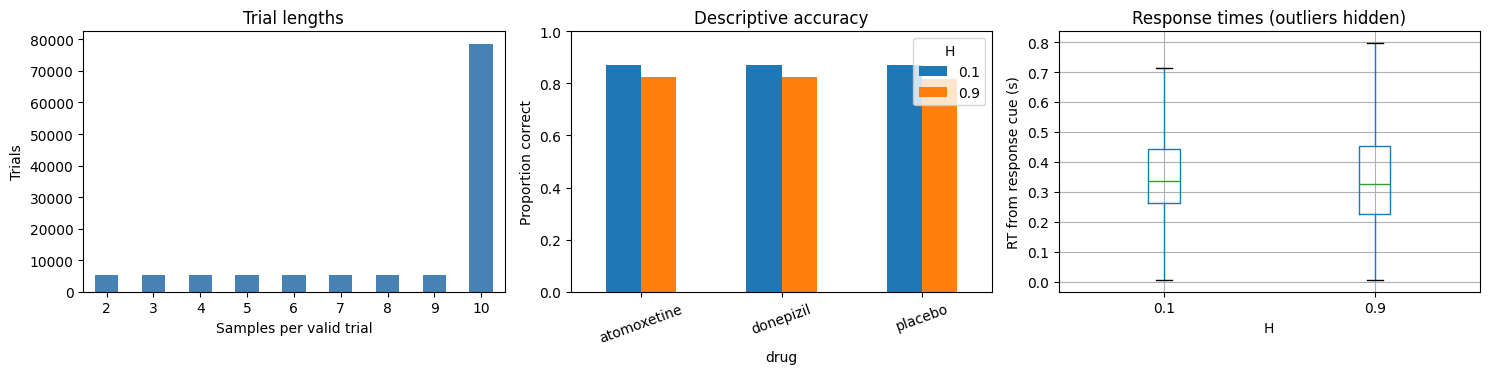

In [5]:
summary_df = trials_df.loc[valid].groupby(["drug", "H"]).agg(
    participants=("participant", "nunique"), trials=("trial_id", "size"),
    accuracy=("accuracy", "mean"), median_rt_s=("rt_s", "median"),
    mean_samples=("n_samples", "mean"))
display(summary_df)
display(stimuli_df.loc[stimuli_df.sample_in_trial.gt(1)].groupby("H").agg(
    transitions=("switch", "size"), observed_switch_rate=("switch", "mean")))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
length_counts.plot.bar(ax=axes[0], color="steelblue", rot=0)
axes[0].set(xlabel="Samples per valid trial", ylabel="Trials", title="Trial lengths")
summary_df.accuracy.unstack("H").plot.bar(ax=axes[1], rot=20)
axes[1].set(ylabel="Proportion correct", title="Descriptive accuracy", ylim=(0, 1))
trials_df.loc[valid].boxplot(column="rt_s", by="H", ax=axes[2], showfliers=False)
axes[2].set(xlabel="H", ylabel="RT from response cue (s)", title="Response times (outliers hidden)")
fig.suptitle("")
fig.tight_layout()
plt.show()

## Use the loaded tables

`metadata_df`, `trials_df`, and `stimuli_df` remain in memory. For example:
```python
analysis_trials = trials_df.loc[trials_df.analysis_valid].copy()
analysis_stimuli = stimuli_df.loc[stimuli_df.analysis_valid & stimuli_df.presented].copy()
```
Keep raw trial IDs when filtering. To inspect exclusions, use `trials_df.loc[~trials_df.analysis_valid]`. The `source_behavior` / `source_sequence` paths are relative to `DATA_DIR` and identify the original blocks. No exclusion deletes source rows.